# Forecasting Soil Nutrient Levels
*Corrected Framework Pipeline*

In [1]:

# Cell 1-2: Setup & Data Acquisition
import pandas as pd
import numpy as np
from biom import load_table
from sklearn.model_selection import train_test_split, GroupKFold, cross_validate
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')


In [2]:

# Cell 3-6: Load & Filter Data
df_map = pd.read_csv('emp_qiime_mapping_qc_filtered_20170912.tsv', sep='\t', low_memory=False, index_col=0)
soil_map = df_map[df_map['empo_3'].str.contains('Soil', na=False, case=False)]

# Target Resolution
for c in ['nitrate_umol_per_l', 'ammonium_umol_per_l', 'ph']:
    soil_map[c] = pd.to_numeric(soil_map[c], errors='coerce')
    
soil_map['total_nitrogen'] = soil_map['nitrate_umol_per_l'].fillna(0) + soil_map['ammonium_umol_per_l'].fillna(0)
soil_map = soil_map[soil_map['total_nitrogen'] > 0] # strictly real data

table = load_table('emp_deblur_150bp.release1.biom')
common_samples = list(set(soil_map.index) & set(table.ids(axis='sample')))
soil_map = soil_map.loc[common_samples]

if len(common_samples) > 500:
    np.random.seed(42)
    common_samples = list(np.random.choice(common_samples, 500, replace=False))
    soil_map = soil_map.loc[common_samples]

otu_counts = []
for sample_id in common_samples:
    otu_counts.append(table.data(sample_id, dense=True))

otu_taxonomy = {}
for obs_id, obs_meta, _ in table.iter(axis='observation'):
    tax = ['Unknown']*7
    if isinstance(obs_meta, dict) and 'taxonomy' in obs_meta:
         tax = obs_meta['taxonomy']
    elif isinstance(obs_meta, list) or isinstance(obs_meta, tuple):
         tax = obs_meta
    clean_tax = [t.strip() for t in tax[:6] if isinstance(t, str) and t.strip() not in ('', '__')]
    otu_taxonomy[str(obs_id)] = '; '.join(clean_tax) if clean_tax else str(obs_id)

import scipy.sparse as sp
otu_sparse = sp.csr_matrix(otu_counts)
col_sums = otu_sparse.sum(axis=0)
keep_cols = np.where(col_sums > 5)[1]
otu_counts = [table.data(sid, dense=True)[keep_cols] for sid in common_samples]

otu_df = pd.DataFrame(np.array(otu_counts), index=common_samples)
otu_df.columns = otu_df.columns.astype(str) # Fix mixed type column issue
otu_df.rename(columns={str(col): otu_taxonomy.get(str(col), str(col)) for col in otu_df.columns}, inplace=True)
otu_rel = otu_df.div(otu_df.sum(axis=1).replace(0, 1), axis=0)


In [3]:

# Cell 9: CLR Transformation & Top Biological Feature Filter
otu_pseudo = otu_rel + 1e-6
otu_clr = np.log(otu_pseudo.div(np.exp(np.mean(np.log(otu_pseudo), axis=1)), axis=0))
otu_clr_filtered = otu_clr[otu_clr.var().sort_values(ascending=False).head(150).index]


In [4]:

# Cell 11: Alpha Diversity Metrics
p = otu_rel + 1e-10
div_df = pd.DataFrame({
    'shannon_entropy': -np.sum(p * np.log(p), axis=1),
    'simpson_index': 1 - np.sum(p**2, axis=1),
    'observed_taxa': (otu_df > 0).sum(axis=1)
}, index=common_samples)

# Cell 12: Merge Features
X = pd.concat([otu_clr_filtered, div_df], axis=1)
X.columns = X.columns.astype(str) # Force all column names to string for Scikit-Learn
if 'ph' in soil_map.columns:
    X['ph'] = soil_map['ph'].fillna(soil_map['ph'].mean())
y = soil_map['total_nitrogen']


In [5]:

# Cell 13: Train Models (RF, GB, Ridge) & Dummy Baseline
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'Null Baseline': DummyRegressor(strategy='mean'),
    'RF': RandomForestRegressor(n_estimators=100, random_state=42),
    'GB': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)


In [6]:

# Cell 16: Spatial Block Cross Validation
spatial_groups = pd.to_numeric(soil_map['latitude_deg'], errors='coerce').fillna(0).round().astype(int)
gkf = GroupKFold(n_splits=min(5, len(np.unique(spatial_groups))))
for name, model in models.items():
    cv_scores = cross_validate(model, scaler.fit_transform(X), y, cv=gkf, groups=spatial_groups, scoring='r2')
    print(f"Spatial Block CV (R2) mean for {name}: {cv_scores['test_score'].mean():.4f}")


Spatial Block CV (R2) mean for Null Baseline: -710558.7828


Spatial Block CV (R2) mean for RF: -901974.5596


Spatial Block CV (R2) mean for GB: -463780.3096


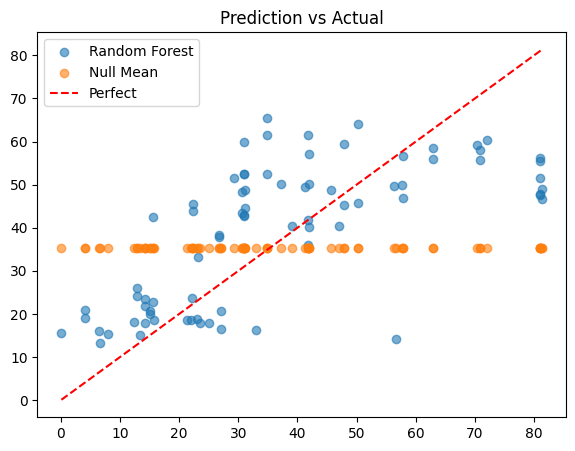

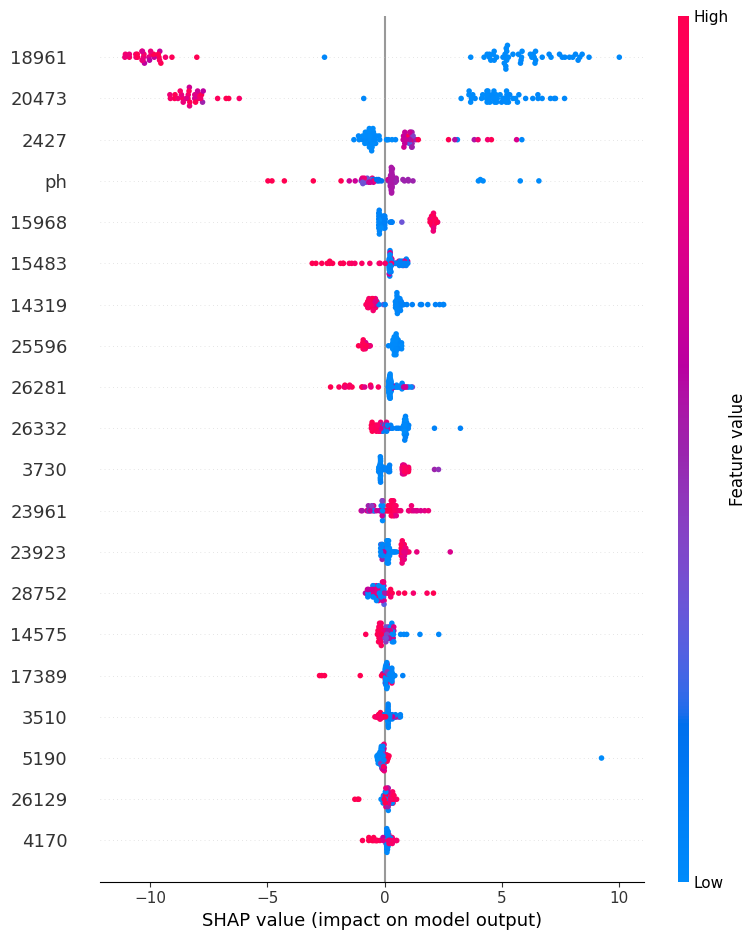

In [7]:

# Cell 14-15: Evaluation & SHAP Interpretability
preds = {name: model.predict(X_test_scaled) for name, model in models.items()}

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, preds['RF'], alpha=0.6, label='Random Forest')
plt.scatter(y_test, preds['Null Baseline'], alpha=0.6, label='Null Mean')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect')
plt.title('Prediction vs Actual')
plt.legend()
plt.show()

# SHAP Interpretation
explainer = shap.TreeExplainer(models['RF'])
shap_values = explainer.shap_values(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)
